In [1]:
import os
import pandas as pd
import observability as obs

In [2]:
#Accepts a target list of stars 
stars = pd.read_csv('test_data/testlist.txt')
star_list = stars['ID']

In [3]:
#extracts the star information from Simbad:
# TIC ID, TOI ID, Gaia DR3 ID, HD, GJ, Hip, 2MASS, and main  identifiers
# RA and Dec in decimal and sexagesimal
# Distance and parallax
# H mag, R mag, K mag
# V mag: comes from either Simbad, Oja et al. 1987-1994 catalog or the Tycho2 catalog
# Output is a pandas dataframe that contains all the information
test_df = obs.extract_star_information(star_list, tic_flag = True, toi_flag = True, gaia_flag = True, hd_flag = True, 
                                       gj_flag = True, main_flag = True, hip_flag = True, tmass_flag = True, verbose = True)

Querying SIMBAD for targets
Finished SIMBAD query
Extracting V magnitudes
Star #: 0
Found TIC290131778 in TYCHO
Star #: 1
Found TIC25375553 in TYCHO
Star #: 2
Found TIC441462736 in TYCHO
Star #: 3
Found TIC12421862 in TYCHO
Star #: 4
Found TIC9006668 in TYCHO
Star #: 5
Found TIC37749396 in TYCHO
Star #: 6
Found TIC63898957 in TYCHO
Star #: 7
Found TIC164767175 in TYCHO
Star #: 8
Found TIC47316976 in TYCHO
Star #: 9
Found TIC328350926 in TYCHO
Star #: 10
Found TIC9858404 in TYCHO
Star #: 11
Found TIC1129033 in TYCHO
Star #: 12
Found TIC120896927 in TYCHO
Star #: 13
Found TIC94986319 in TYCHO
Star #: 14
Found TIC117979455 in TYCHO
Star #: 15
Found TIC189013224 in TYCHO
Star #: 16
Found TIC117979850 in TYCHO
Star #: 17
Found TIC31374837 in TYCHO
Star #: 18
Found TIC468880077 in TYCHO
Star #: 19
Found TIC179034327 in TYCHO
Star #: 20
Found TIC452808876 in TYCHO
Star #: 21
Found TIC98796344 in TYCHO
Star #: 22
Found TIC64071894 in TYCHO
Star #: 23
Found TIC4646810 in TYCHO
Star #: 24
Found 

In [4]:
#Filter your target list by the CHARA declination limit which is > -20 degrees
dec_filtered = obs.filter_by_chara_limits(test_df)
print("Number of stars that made the cut:", len(dec_filtered), "out of", len(test_df))

Number of stars that made the cut: 548 out of 597


In [5]:
#Filter the declination filtered list of stars by instrument using the below commands:
# Criteria are:
# PAVO: Rmag <= 7.5 or Vmag < 7.0 and Angular diameter > 0.25 mas
# MIRC-X: Hmag <= 7.5 and Angular diameter > 0.35 mas
# MYSTIC: Kmag <= 6.5 and Angular diameter > 0.35 mas
# Classic: Hmag <= 7.0 and Angular diameter > 0.50 mas
# SPICA: Rmag <=5.5 or Vmag < 5.0 and Angular diameter > 0.25 mas

pavo_targets = obs.get_targets(dec_filtered, 'PAVO', verbose = True)
mircx_targets = obs.get_targets(dec_filtered, 'MIRCX', verbose = True)
mystic_targets = obs.get_targets(dec_filtered, 'MYSTIC', verbose = True)
classic_targets = obs.get_targets(dec_filtered, 'Classic', verbose = True)
spica_targets = obs.get_targets(dec_filtered, 'SPICA', verbose = True)

There are  8 out of  548  targets observable with PAVO.
There are  11 out of  548  targets observable with MIRC-X.
There are  11 out of  548  targets observable with MYSTIC.
There are  3 out of  548  targets observable with Classic.
There are  2 out of  548  targets observable with SPICA.


In [6]:
#Check what time of year the targets are best observable in
pavo_df = obs.time_of_year(pavo_targets)
mircx_df = obs.time_of_year(mircx_targets)
mystic_df = obs.time_of_year(mystic_targets)
classic_df = obs.time_of_year(classic_targets)
spica_df = obs.time_of_year(spica_targets)

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Observable SPICA targets'}, xlabel='RA (hour)', ylabel='Star ID'>)

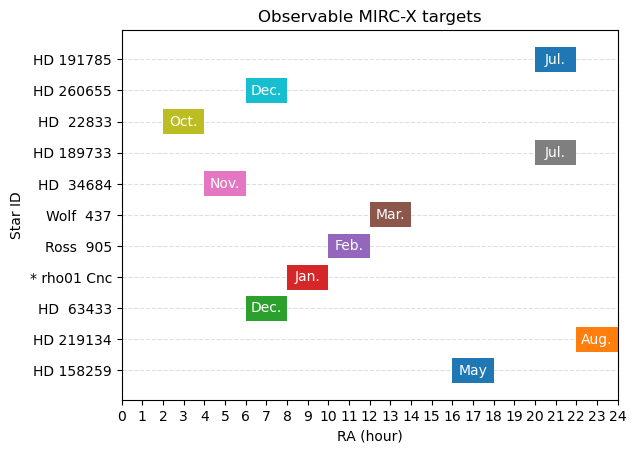

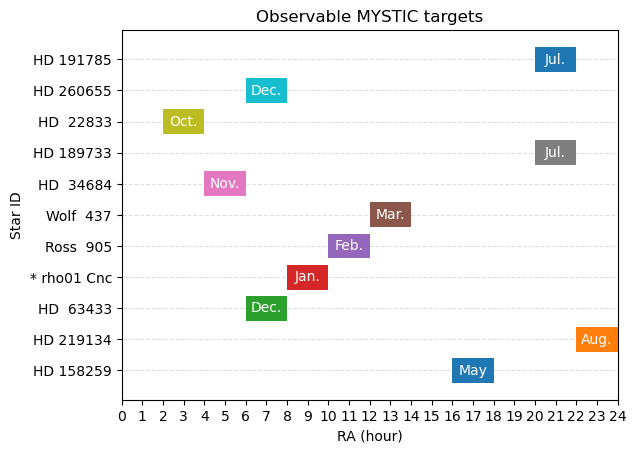

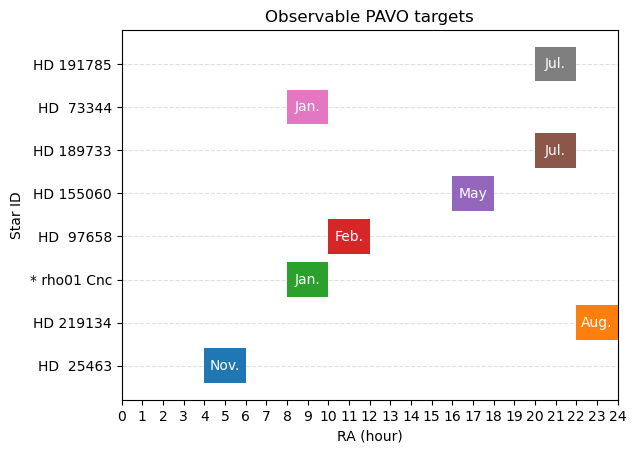

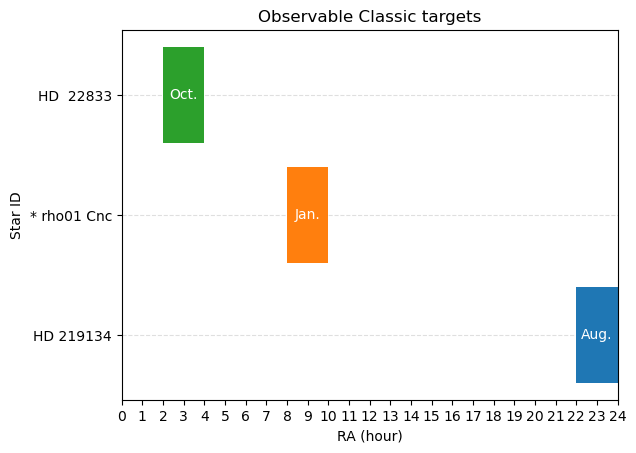

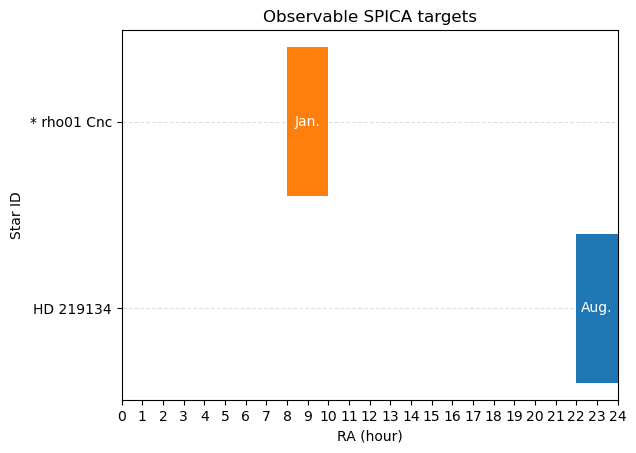

In [7]:
#Observability plot of your targets
obs.obsplot(mircx_df, 'MIRC-X')
obs.obsplot(mystic_df, 'MYSTIC')
obs.obsplot(pavo_df, 'PAVO')
obs.obsplot(classic_df, 'Classic')
obs.obsplot(spica_df, 'SPICA')